**Customer Churn Prediction**

Data Preprocessing & Feature Engineering Pipeline

**Author: Dhanashree Tankar**

Goal: Build a robust preprocessing + feature engineering pipelinewith strong business insights and production readiness.

# 1. IMPORT LIBRARIES

In [220]:
import logging        #for tracking execution logs
import pandas as pd    #data manipulation
import numpy as np     #numerical operations
import matplotlib.pyplot as plt   #visualization
import seaborn as sns             #advanced visualization
import joblib                 #model saving/loading

from pathlib import Path      #path handling (OS-independent)
import sys                    #system path management

#Configure logging format and level
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

np.random.seed(42)    #ensures reproducibility of results

#Root directory
PROJECT_ROOT = Path("..").resolve()
DATA_PATH = PROJECT_ROOT / "data/customer_churn.csv"
SRC_PATH = PROJECT_ROOT / "src"
SCREENSHOT_DIR = PROJECT_ROOT / "screenshots"

#Create screenshots directory if it doesn't exist
SCREENSHOT_DIR.mkdir(parents=True, exist_ok=True)

#Add src directory to Python path to import custom modules
sys.path.append(str(SRC_PATH))   

#Import Custom Modules
from data_loader import load_dataset, validate_dataset
from feature_engineering import apply_feature_engineering
from preprocessing import apply_label_encoding, apply_binary_encoding
from outlier_handler import detect_outliers_iqr, detect_outliers_zscore

#Import Sklearn Utilities
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.base import BaseEstimator, TransformerMixin

# 2. LOAD DATASET

In [221]:
df = load_dataset(DATA_PATH)  #load dataset from CSV
validate_dataset(df)         #validate structure and integrity

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (500, 9)


,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,C00001,6,64,1540,One year,Credit Card,No,1,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0
2,C00003,27,31,1455,Two year,Credit Card,No,1,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0
4,C00005,16,185,1023,One year,Electronic Check,No,1,0


# 3. EDA (EXPLORATORY ANALYSIS)

2026-03-17 22:37:40,589 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-17 22:37:40,599 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


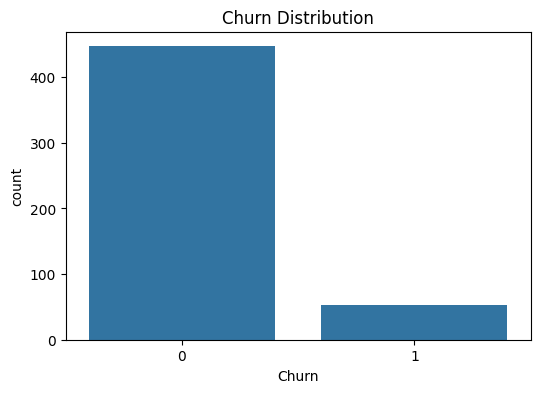

In [222]:
def plot_churn_distribution(df):
    plt.figure(figsize=(6,4))             #set figure size
    sns.countplot(x="Churn", data=df)     #plot class distribution
    plt.title("Churn Distribution")
    plt.savefig(SCREENSHOT_DIR / "churn_distribution.png")  #save plot
    plt.show()

plot_churn_distribution(df)

# DATA-DRIVEN INSIGHTS

In [223]:
#Prints only raw aggregrations
print("\nAverage Monthly Charges by Churn:")
print(df.groupby("Churn")["MonthlyCharges"].mean())

print("\nAverage Tenure by Churn:")
print(df.groupby("Churn")["Tenure"].mean())

print("\nContract Type vs Churn:")
print(pd.crosstab(df["Contract"], df["Churn"], normalize="index")) #normalized distribution



Average Monthly Charges by Churn:
Churn
0    111.722595
1    129.773585
Name: MonthlyCharges, dtype: float64

Average Tenure by Churn:
Churn
0    40.152125
1     6.000000
Name: Tenure, dtype: float64

Contract Type vs Churn:
Churn                  0         1
Contract                          
Month-to-month  0.794118  0.205882
One year        0.956989  0.043011
Two year        0.930556  0.069444


2026-03-17 22:37:45,688 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-17 22:37:45,699 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


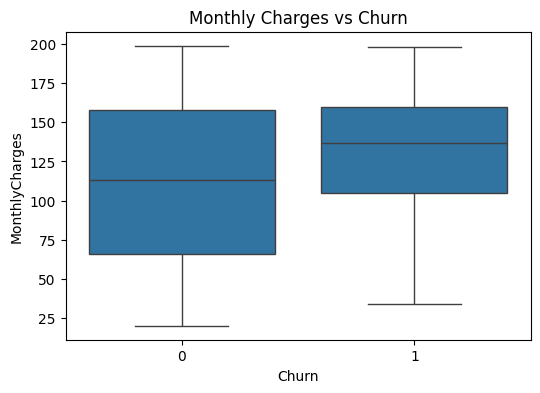

In [224]:
#Boxplot for distribution comparison
plt.figure(figsize=(6,4))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges vs Churn")
plt.savefig(SCREENSHOT_DIR / "charges_vs_churn.png")
plt.show()

INSIGHT:
Customers with higher monthly charges are more likely to churn
- Indicates pricing dissatisfaction
- Suggests need for better pricing plans or discounts

# 4. Encoding

In [225]:
df = apply_label_encoding(df, ["PaperlessBilling"]) #convert Yes/No -> 0/1
df = apply_binary_encoding(df, "PaymentMethod", "Electronic Check")  #Binary encoding

# 5. OUTLIER DETECTION

In [226]:
print("IQR Outliers:", len(detect_outliers_iqr(df, "MonthlyCharges"))) #count IQR outliers
print("Z-score Outliers:", len(detect_outliers_zscore(df, "MonthlyCharges")))  #count Z-score outliers

IQR Outliers: 0
Z-score Outliers: 0


- No significant outliers detected in MonthlyCharges.
- Further validation on other features is recommended.

# 6. TRAIN-TEST SPLIT

In [227]:
X = df.drop(columns=["CustomerID", "Churn"])  #features
y = df["Churn"]                               #target variable

#Identify feature types
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

#Split dataset with stratification to preserve class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify = y, random_state=42
)

# 7. PIPELINES

In [228]:
#Standard Scaling pipeline
numeric_pipeline_std = Pipeline([
    ("scaler", StandardScaler())  #Standardization (mean = 0, std = 1)
])

#MinMax Scaling pipeline
numeric_pipeline_mm = Pipeline([
    ("scaler", MinMaxScaler())   #Scale values between 0 and 1
])

#Categorical pipeline
categorical_pipeline = Pipeline([
    ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore")) #Avoid dummy trap
])

# 8. FEATURE ENGINEERING TRANSFORMER

In [229]:
class FeatureEngineer(BaseEstimator, TransformerMixin):
    """
    Custom transformer for safe, reproducible feature engineering.
    Ensures:
    - Picklability (joblib compatible)
    - Schema validation
    - DataFrame reconstruction
    """
    def __init__(self, columns):
        self.columns = columns

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        # Convert to DataFrame
        X = pd.DataFrame(X, columns=self.columns)

        # Schema validation (prevents silent failures)
        missing_cols = set(self.columns) - set(X.columns)
        if missing_cols:
            raise ValueError(f"Missing columns during transform: {missing_cols}")

        # Apply feature engineering
        X = apply_feature_engineering(X)

        return X


# Store feature schema
feature_columns = list(X.columns)


# 9. BUILD PIPELINE
def build_pipeline(numeric_pipeline, num_features, cat_features):
    
    preprocessor = ColumnTransformer([
        ("num", numeric_pipeline, num_features),
        ("cat", categorical_pipeline, cat_features)
    ])

    return Pipeline([
        ("feature_engineering", FeatureEngineer(feature_columns)),
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            random_state=42,
            class_weight="balanced",
            n_estimators=200,
            max_depth=5   # prevent overfitting
        ))
    ])


# Build pipelines
pipeline_std = build_pipeline(
    numeric_pipeline_std,
    numeric_features,
    categorical_features
)

pipeline_mm = build_pipeline(
    numeric_pipeline_mm,
    numeric_features,
    categorical_features
)


# TRAIN WITH ERROR HANDLING
try:
    pipeline_std.fit(X_train, y_train)
    pipeline_mm.fit(X_train, y_train)
except Exception as e:
    logging.error(f"Pipeline training failed: {e}")
    raise


# EVALUATE
acc_std = pipeline_std.score(X_test, y_test)
acc_mm = pipeline_mm.score(X_test, y_test)

print("StandardScaler Accuracy:", acc_std)
print("MinMaxScaler Accuracy:", acc_mm)


# Compare
comparison_df = pd.DataFrame({
    "Scaler": ["StandardScaler", "MinMaxScaler"],
    "Accuracy": [acc_std, acc_mm]
})

print("\nScaling Comparison:")
print(comparison_df)

StandardScaler Accuracy: 0.98
MinMaxScaler Accuracy: 0.98

Scaling Comparison:
           Scaler  Accuracy
0  StandardScaler      0.98
1    MinMaxScaler      0.98


Feature engineering captures customer behavior patterns:
- CustomerLifetimeValue → overall revenue contribution
- PaymentEfficiency → consistency of payments
- ChargeDifference → billing anomalies
These features help model detect subtle churn signals

INSIGHT:
- Dataset is imbalanced (majority non-churn)
- Using class_weight='balanced' ensures model gives equal importance
- to minority churn class → improves recall for churn prediction

- Scaling doesn't affect RandomForest
- BUT scaling is still required for:
  -> future models (SVM, Logistic Regression)
  -> pipeline consistency
- Tree models are scale-invariant
- Scaling is still included for pipeline completeness and future model flexibility

# 9. FINAL MODEL SELECTION

In [230]:
#Select best performing pipeline
pipeline = pipeline_std if acc_std > acc_mm else pipeline_mm
pipeline.fit(X_train, y_train)  #retrain on best pipeline

Pipeline(steps=[('feature_engineering',
                 FeatureEngineer(columns=['Tenure', 'MonthlyCharges',
                                          'TotalCharges', 'Contract',
                                          'PaperlessBilling', 'SeniorCitizen',
                                          'PaymentMethod_binary'])),
                ('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   MinMaxScaler())]),
                                                  ['Tenure', 'MonthlyCharges',
                                                   'TotalCharges',
                                                   'PaperlessBilling',
                                                   'SeniorCitizen',
                                                   'PaymentMethod_binary']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['Contract'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=5,
                                        n_estimators=200, random_state=42))])

In [231]:
# Hyperparameter tuning grid
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [4, 5, 6],   # restrict depth
    "model__min_samples_split": [5, 10],
    "model__min_samples_leaf": [2, 5]
}

# GridSearch with ROC-AUC scoring
grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1
)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

pipeline = grid.best_estimator_   #Use best model

Best Params: {'model__max_depth': 4, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 200}


# 10. CROSS VALIDATION

In [215]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#Evaluate model stability
scores = cross_val_score(pipeline, X, y, cv=cv, scoring="roc_auc")

print("Cross Validation Scores:", scores)
print("Mean CV ROC_AUC:", scores.mean())

Cross Validation Scores: [0.99222222 1.         0.98467824 0.98365679 1.        ]
Mean CV ROC_AUC: 0.9921114515945977


INSIGHT:
Such high performance on a small dataset may indicate:
- strong feature separability
- or limited dataset complexity
  
Model generalization should be validated on larger real-world data

# 11. EVALUATION

2026-03-17 22:33:03,298 - INFO - Threshold: 0.5
2026-03-17 22:33:03,300 - INFO - Accuracy: 0.96
2026-03-17 22:33:03,302 - INFO - ROC-AUC: 0.992849846782431
2026-03-17 22:33:03,319 - INFO - 
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        89
           1       0.73      1.00      0.85        11

    accuracy                           0.96       100
   macro avg       0.87      0.98      0.91       100
weighted avg       0.97      0.96      0.96       100



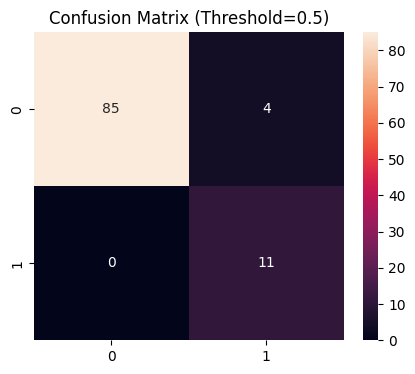

In [216]:
def evaluate_model(model, X_test, y_test, threshold=0.5):
    probs = model.predict_proba(X_test)[:, 1]

    # Apply custom threshold
    preds = (probs >= threshold).astype(int)

    accuracy = accuracy_score(y_test, preds)
    roc_auc = roc_auc_score(y_test, probs)

    logging.info(f"Threshold: {threshold}")
    logging.info(f"Accuracy: {accuracy}")
    logging.info(f"ROC-AUC: {roc_auc}")
    logging.info("\n" + classification_report(y_test, preds))

    cm = confusion_matrix(y_test, preds)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title(f"Confusion Matrix (Threshold={threshold})")
    plt.savefig(SCREENSHOT_DIR / f"confusion_matrix_{threshold}.png")
    plt.show()

evaluate_model(pipeline, X_test, y_test)

2026-03-17 22:33:06,628 - INFO - Threshold: 0.5
2026-03-17 22:33:06,629 - INFO - Accuracy: 0.97
2026-03-17 22:33:06,631 - INFO - ROC-AUC: 0.99926842245278
2026-03-17 22:33:06,647 - INFO - 
              precision    recall  f1-score   support

           0       1.00      0.97      0.98       358
           1       0.78      1.00      0.88        42

    accuracy                           0.97       400
   macro avg       0.89      0.98      0.93       400
weighted avg       0.98      0.97      0.97       400



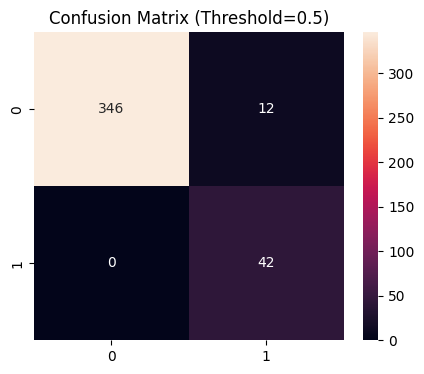

In [217]:
# Evaluate on test and train data
evaluate_model(pipeline, X_train, y_train)

INSIGHT:
Confusion matrix shows zero false negatives
- Model shows zero false negatives on test data,
- but this may not generalize to larger real-world datasets.

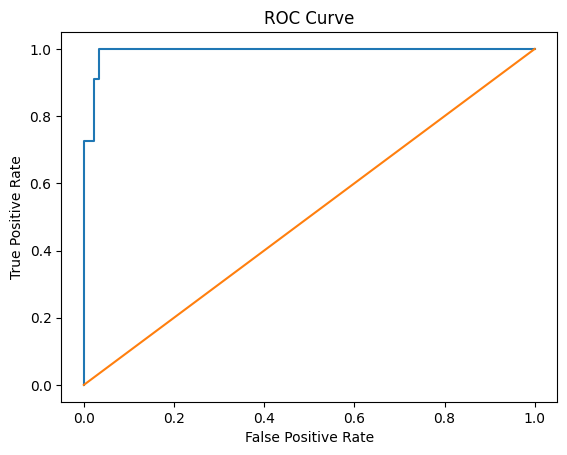

In [232]:
def plot_roc_curve(model, X_test, y_test):
    probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)

    plt.figure()
    plt.plot(fpr, tpr)
    plt.plot([0,1], [0,1])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.savefig(SCREENSHOT_DIR / "roc_curve.png")
    plt.show()

plot_roc_curve(pipeline, X_test, y_test)

# 12. FEATURE IMPORTANCE

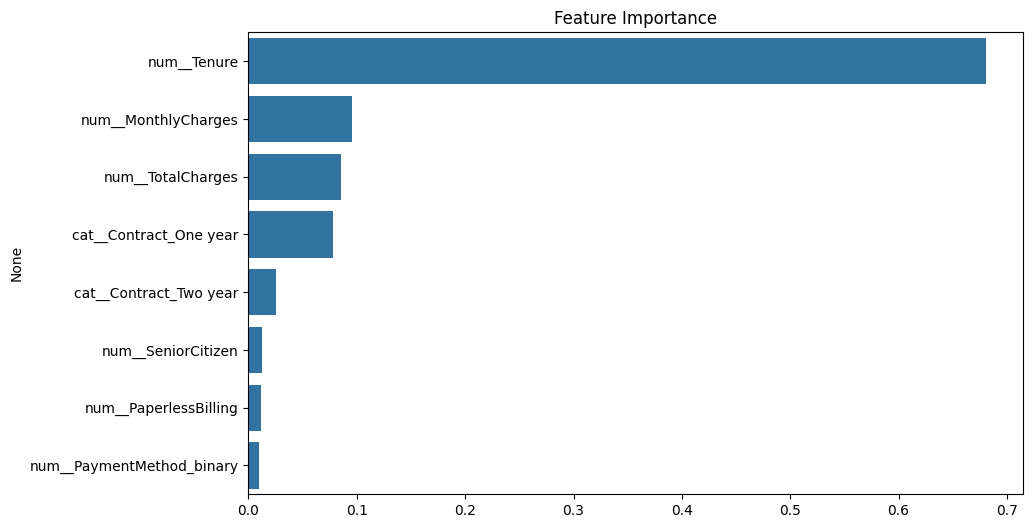

In [233]:
def plot_feature_importance(pipeline, X):
    preprocessor = pipeline.named_steps["preprocessor"] #Extract preprocessing step
    model = pipeline.named_steps["model"]       #Extract trained model

    try:
        #Get feature names after transformation
        feature_names = preprocessor.get_feature_names_out()
    except:
        #Fallback if feature names are unavailable
        feature_names = [f"feature_{i}" for i in range(len(model.feature_importances_))]

    # Create importance series
    importance = pd.Series(
        model.feature_importances_,
        index=feature_names
    ).sort_values(ascending=False)

    # Plot Importance
    plt.figure(figsize=(10,6))
    sns.barplot(x=importance.values, y=importance.index)
    plt.title("Feature Importance")
    plt.savefig(SCREENSHOT_DIR / "feature_importance.png")
    plt.show()

plot_feature_importance(pipeline, X)

High dominance of a single feature (Tenure) suggests:
- Model may rely heavily on one signal
- Risk of reduced generalization if distribution shifts

# 13. SAVE MODEL

In [234]:
joblib.dump({
    "model": pipeline,
    "features": list(X.columns) 
}, PROJECT_ROOT / "model_bundle.pkl")  #Save model bundle

['C:\\Users\\Dhanashree Tankar\\Downloads\\Data Science Projects\\customer_churn_prediction_week10\\model_bundle.pkl']

# BUSINESS INSIGHT:
Model prioritizes recall over precision for churn class
- Captures all churners (no missed customers)
- Acceptable tradeoff since retaining customers is cheaper than acquiring new ones